## Bagging (Bootstrap Aggregating)

## 📊Implement Bagging Classifier for Course Completion Prediction


## 1.Import Libraries

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import BaggingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('main_clean_data.csv')

In [3]:
df.head()

,age,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,...,education_background_Undergrad,education_background_WorkingPro,course_level_Advanced,course_level_Beginner,course_level_Intermediate,course_category_Business,course_category_Data,course_category_Design,course_category_Marketing,course_category_Programming
0,1.395524,-0.975477,-1.886282,-1.062757,-1.540257,-0.369750,-1.458420,-0.344933,-1.018644,-1.743625,...,1,0,0,0,1,1,0,0,0,0
1,-1.314686,0.493337,-0.213248,1.101746,-1.201238,-1.159715,1.706847,-0.344933,-1.153411,1.423907,...,1,0,0,0,1,0,0,0,0,1
2,0.130760,0.827158,-1.328604,-1.117974,-0.523201,-1.949681,-0.930876,-1.357553,-0.352295,-0.320531,...,0,0,1,0,0,0,0,0,0,1
3,0.311440,-1.109006,1.794392,0.538533,2.256752,0.815198,1.179302,-1.357553,-0.569420,0.276250,...,1,0,0,1,0,0,0,1,0,0
4,0.311440,-0.975477,0.455965,1.664958,1.171892,0.815198,-0.930876,-1.357553,-0.135170,-0.283806,...,0,1,1,0,0,1,0,0,0,0


## 2: Feature and Target Selection

In [4]:
# ==========================================================
# Features and Target
# ==========================================================

X = df.drop('completion_status', axis=1)

y = df['completion_status']

## 3: Train Test Split

In [5]:
# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## 4: Base Model (Decision Tree)

In [6]:
# ==========================================================
# Base Model
# ==========================================================

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

base_acc = accuracy_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Accuracy :", base_acc * 100)

Decision Tree Accuracy : 77.30900798175598


## 5: Bagging Classifier

In [7]:
# ==========================================================
# Bagging Classifier
# ==========================================================

bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bag_clf.fit(
    X_train,
    y_train
)

y_pred_bag = bag_clf.predict(X_test)

bag_acc = accuracy_score(
    y_test,
    y_pred_bag
) 

print("Bagging Accuracy :", bag_acc * 100)

Bagging Accuracy : 84.49258836944128


## 6: Classification Report

In [8]:
# ==========================================================
# Classification Report
# ==========================================================

print(
    classification_report(
        y_test,
        y_pred_bag
    )
)

              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88       564
         1.0       0.81      0.74      0.77       313

    accuracy                           0.84       877
   macro avg       0.84      0.82      0.83       877
weighted avg       0.84      0.84      0.84       877



## 7: Confusion Matrix

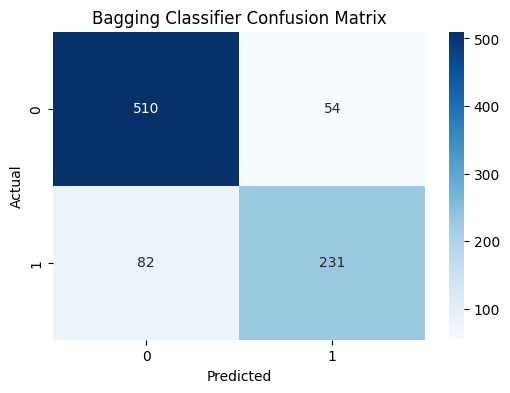

In [9]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred_bag
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Bagging Classifier Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 8: Accuracy Comparison Graph

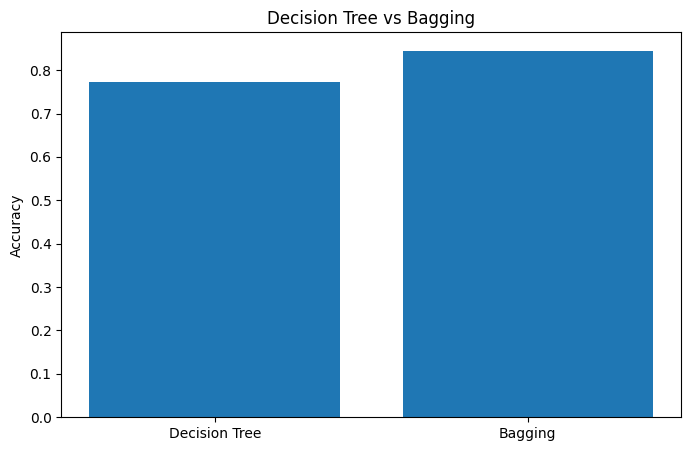

In [10]:
# ==========================================================
# Accuracy Comparison
# ==========================================================

models = [
    'Decision Tree',
    'Bagging'
]

scores = [
    base_acc,
    bag_acc
]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    scores
)

plt.title(
    "Decision Tree vs Bagging"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

# ROC AUC Score


In [11]:
# ==========================================================
# ROC AUC Score
# ==========================================================

from sklearn.metrics import roc_auc_score

# Probability for Positive Class
y_prob = bag_clf.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC Score :{auc_score:.4f}")

ROC-AUC Score :0.9189


# ROC Curve


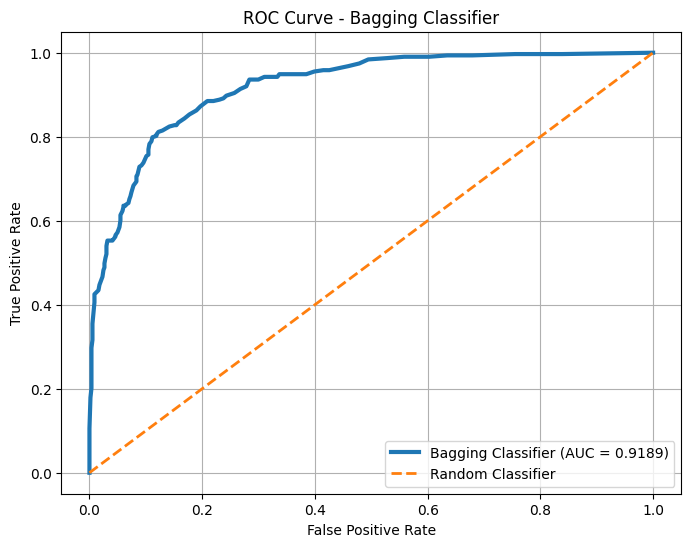

In [12]:
# ==========================================================
# ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'Bagging Classifier (AUC = {auc_score:.4f})'
)

# Random Classifier Line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2,
    label='Random Classifier'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Bagging Classifier"
)

plt.legend()

plt.grid(True)

plt.show()

## 📊Implement Bagging Regressor for Final Score Prediction

## 9: Import Libraries

In [13]:
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import BaggingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 10: Feature and Target

In [14]:
# ==========================================================
# Features and Target
# ==========================================================

X = df.drop(
    'final_score',
    axis=1
)

y = df['final_score']

## 11: Train Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## 12: Base Regressor

In [16]:
# ==========================================================
# Decision Tree Regressor
# ==========================================================

dt_reg = DecisionTreeRegressor(
    random_state=42
)

dt_reg.fit(
    X_train,
    y_train
)

y_pred_dt = dt_reg.predict(
    X_test
)

base_r2 = r2_score(
    y_test,
    y_pred_dt
)

print(
    "Decision Tree R2 Score :",
    base_r2 * 100
)

Decision Tree R2 Score : 23.146408667921904


## 13: Bagging Regressor

In [17]:
# ==========================================================
# Bagging Regressor
# ==========================================================

bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42
)

bag_reg.fit(
    X_train,
    y_train
)

y_pred_bag = bag_reg.predict(
    X_test
)

bag_r2 = r2_score(
    y_test,
    y_pred_bag
)

print(
    "Bagging R2 Score :",
    bag_r2 * 100
) 

Bagging R2 Score : 62.15821745830768


## 14: Regression Metrics

In [18]:
# ==========================================================
# Evaluation Metrics
# ==========================================================

mae = mean_absolute_error(
    y_test,
    y_pred_bag
)

mse = mean_squared_error(
    y_test,
    y_pred_bag
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred_bag
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 6.546665906499431
MSE : 65.09693820068416
RMSE : 8.068267360510816
R2 : 0.6215821745830769


## 15: Actual vs Predicted Graph

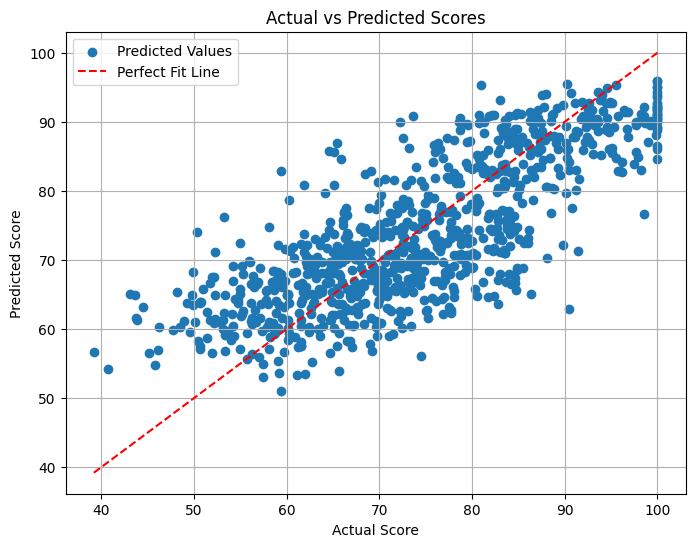

In [20]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_bag,
    label="Predicted Values"
)

# Perfect Fit Line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect Fit Line"
)

plt.xlabel("Actual Score")

plt.ylabel("Predicted Score")

plt.title("Actual vs Predicted Scores")

plt.legend()

plt.grid(True)

plt.show()

## 16: Regression Comparison Graph

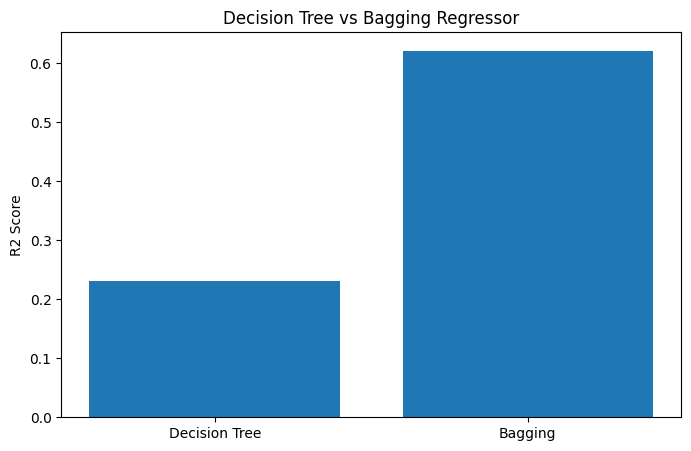

In [ ]:
# ==========================================================
# R2 Comparison
# ==========================================================

models = [
    'Decision Tree',
    'Bagging'
]

scores = [
    base_r2,
    bag_r2
]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    scores
)

plt.ylabel(
    "R2 Score"
)

plt.title(
    "Decision Tree vs Bagging Regressor"
)

plt.show()

# Bagging Classifier Analysis

## Overview

Bagging (Bootstrap Aggregating) is an ensemble learning technique that improves model performance by training multiple models on different bootstrap samples of the dataset and combining their predictions. Bagging helps reduce variance, improve stability, and enhance prediction accuracy.

In this project, a Decision Tree Classifier was used as the base learner for the Bagging Classifier to predict student course completion status.

---

## Classification Results

### Base Model Performance

| Model | Accuracy |
|---------|---------|
| Decision Tree Classifier | 77.31% |
| Bagging Classifier | 84.49% |

### Improvement

The Bagging Classifier improved the accuracy from **77.31%** to **84.49%**, resulting in a significant increase in classification performance.

---

## Classification Report

| Class | Precision | Recall | F1-Score |
|---------|---------|---------|---------|
| 0 (Not Completed) | 0.86 | 0.90 | 0.88 |
| 1 (Completed) | 0.81 | 0.74 | 0.77 |

### Macro Average

- Precision: 0.84
- Recall: 0.82
- F1-Score: 0.83

### Weighted Average

- Precision: 0.84
- Recall: 0.84
- F1-Score: 0.84

---

## Interpretation

- The model achieved strong overall classification performance.
- Students who did not complete the course were identified with high accuracy.
- The model maintained a good balance between precision and recall.
- The F1-score values indicate stable and reliable classification performance.
- Bagging significantly reduced overfitting compared to a single Decision Tree model.

---

## ROC-AUC Analysis

### ROC-AUC Score

**ROC-AUC = 0.9189**

The ROC-AUC score measures the model's ability to distinguish between students who completed the course and those who did not.

### Interpretation

| AUC Score | Performance |
|------------|------------|
| 0.50 | Poor |
| 0.60 - 0.70 | Fair |
| 0.70 - 0.80 | Good |
| 0.80 - 0.90 | Very Good |
| Above 0.90 | Excellent |

The obtained ROC-AUC score of **0.9189** indicates excellent classification capability and strong class separation performance.

---

## Bagging Classifier Conclusion

The Bagging Classifier achieved an accuracy of **84.49%**, outperforming the base Decision Tree model which achieved **77.31%** accuracy. The ROC-AUC score of **0.9189** demonstrates excellent discrimination capability. These results confirm that Bagging successfully improved prediction accuracy, reduced model variance, and enhanced overall classification robustness.

---

# Bagging Regressor Analysis

## Overview

Bagging Regressor applies bootstrap aggregation to regression problems by combining predictions from multiple Decision Tree Regressors. This ensemble approach reduces variance and improves prediction stability.

The objective was to predict student final scores using academic and engagement-related features.

---

## Regression Results

### Base Model Performance

| Model | R² Score |
|---------|---------|
| Decision Tree Regressor | 23.15% |
| Bagging Regressor | 62.16% |

### Improvement

The Bagging Regressor improved the R² score from **23.15%** to **62.16%**, demonstrating a substantial increase in predictive performance.

---

## Regression Metrics

| Metric | Value |
|----------|----------|
| MAE | 6.55 |
| MSE | 65.10 |
| RMSE | 8.07 |
| R² Score | 0.6216 |

---

### Mean Absolute Error (MAE)

**MAE = 6.55**

On average, the predicted score differs from the actual score by approximately 6.55 marks.

---

### Mean Squared Error (MSE)

**MSE = 65.10**

The average squared prediction error is relatively low, indicating good prediction accuracy.

---

### Root Mean Squared Error (RMSE)

**RMSE = 8.07**

The model's predictions deviate from actual scores by approximately 8.07 marks on average.

---

### R² Score

**R² Score = 0.6216**

This indicates that approximately **62.16% of the variation in student final scores** is explained by the Bagging Regressor model.

---

## Interpretation

- The Bagging Regressor significantly improved performance compared to the single Decision Tree Regressor.
- The model successfully captured important relationships between input features and final scores.
- Error values remained within an acceptable range.
- The ensemble model demonstrated improved stability and generalization capability.

---

## Bagging Regressor Conclusion

The Bagging Regressor achieved an R² score of **0.6216**, outperforming the base Decision Tree Regressor by a large margin. With an MAE of **6.55** and RMSE of **8.07**, the model produced reliable score predictions. The results demonstrate that Bagging effectively reduced prediction variance and improved regression accuracy.

---

# Final Bagging Summary

Bagging proved to be a highly effective ensemble learning technique for both classification and regression tasks.

### Classification Performance

- Base Decision Tree Accuracy: **77.31%**
- Bagging Classifier Accuracy: **84.49%**
- ROC-AUC Score: **0.9189**

### Regression Performance

- Base Decision Tree R² Score: **23.15%**
- Bagging Regressor R² Score: **62.16%**
- MAE: **6.55**
- RMSE: **8.07**

### Overall Conclusion

The Bagging ensemble significantly improved predictive performance compared to individual Decision Tree models. By aggregating multiple bootstrap-based models, Bagging reduced variance, enhanced model stability, and achieved higher accuracy and better generalization. Therefore, Bagging is an effective ensemble technique for predicting student course completion status and final academic performance in the Smart Outcome Predictor project.